In [5]:
import pandas as pd
import os

# 入力・出力ディレクトリ
input_dir = "../analysis_corr"
output_dir = "../analysis_corr2"

# モデル名一覧
models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]

for model in models:
    input_path = os.path.join(
        input_dir,
        f"{model}_piemanpni_allsubjects_with_bronx_clean_corr_df.csv"
    )
    
    output_path = os.path.join(
        output_dir,
        f"{model}_pieman_to_bronx_mean_clean.csv"
    )
    
    # 読み込み
    df = pd.read_csv(input_path)
    
    # parcelごとに平均
    df_mean = df.groupby("parcel").mean(numeric_only=True).reset_index()
    
    # network列を復元
    network = df.groupby("parcel")["network"].first().reset_index()
    df_mean = df_mean.merge(network, on="parcel")
    
    # 保存
    df_mean.to_csv(output_path, index=False)
    
    print(f"Saved: {output_path}")

Saved: ../analysis_corr2/gpt_oss_pieman_to_bronx_mean_clean.csv
Saved: ../analysis_corr2/gpt2_pieman_to_bronx_mean_clean.csv
Saved: ../analysis_corr2/gte_pieman_to_bronx_mean_clean.csv
Saved: ../analysis_corr2/llama_pieman_to_bronx_mean_clean.csv
Saved: ../analysis_corr2/llama3_pieman_to_bronx_mean_clean.csv
Saved: ../analysis_corr2/w2v_pieman_to_bronx_mean_clean.csv


In [6]:
import pandas as pd
import os

# 入力・出力ディレクトリ
input_dir = "../analysis_corr"
output_dir = "../analysis_corr2"

# モデル名一覧
models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]

for model in models:
    input_path = os.path.join(
        input_dir,
        f"{model}_bronx_allsubjects_with_piemanpni_clean_corr_df.csv"
    )
    
    output_path = os.path.join(
        output_dir,
        f"{model}_bronx_to_pieman_mean_clean.csv"
    )
    
    # 読み込み
    df = pd.read_csv(input_path)
    
    # parcelごとに平均
    df_mean = df.groupby("parcel").mean(numeric_only=True).reset_index()
    
    # network列を復元
    network = df.groupby("parcel")["network"].first().reset_index()
    df_mean = df_mean.merge(network, on="parcel")
    
    # 保存
    df_mean.to_csv(output_path, index=False)
    
    print(f"Saved: {output_path}")

Saved: ../analysis_corr2/gpt_oss_bronx_to_pieman_mean_clean.csv
Saved: ../analysis_corr2/gpt2_bronx_to_pieman_mean_clean.csv
Saved: ../analysis_corr2/gte_bronx_to_pieman_mean_clean.csv
Saved: ../analysis_corr2/llama_bronx_to_pieman_mean_clean.csv
Saved: ../analysis_corr2/llama3_bronx_to_pieman_mean_clean.csv
Saved: ../analysis_corr2/w2v_bronx_to_pieman_mean_clean.csv


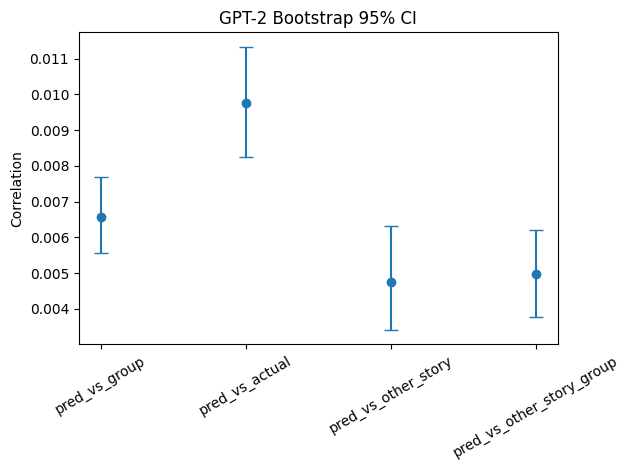

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 読み込み（パスは自分の環境に合わせて）
df = pd.read_csv("../analysis_corr2/gpt2_bronx_to_pieman_mean_clean.csv")

# 対象列（subj_vs_groupを除外）
cols = [c for c in df.columns if c not in ["parcel", "network", "subj_vs_group"]]

# ブートストラップ関数
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# 計算
results = {}
for col in cols:
    mean, lower, upper = bootstrap_ci(df[col].values)
    results[col] = (mean, lower, upper)

# グラフ用データ
labels = list(results.keys())
means = [results[k][0] for k in labels]
lower_err = [results[k][0] - results[k][1] for k in labels]
upper_err = [results[k][2] - results[k][0] for k in labels]

# プロット
plt.figure()
plt.errorbar(labels, means, yerr=[lower_err, upper_err], fmt='o', capsize=5)
plt.xticks(rotation=30)
plt.ylabel("Correlation")
plt.title("GPT-2 Bootstrap 95% CI")
plt.tight_layout()
plt.show()

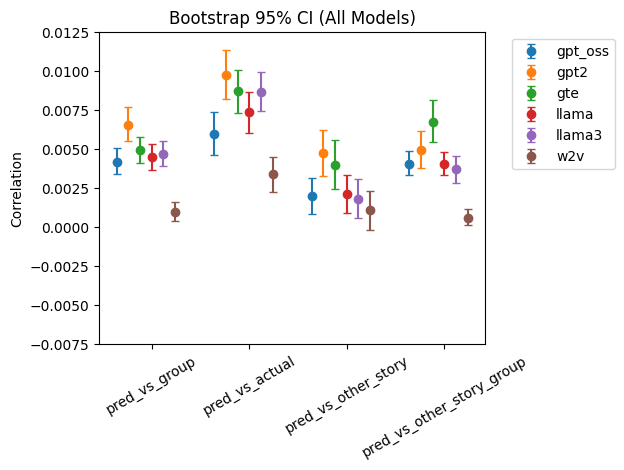

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ディレクトリ
input_dir = "../analysis_corr2/normal_mean"

# モデル一覧
models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]

# 対象列（subj_vs_group除外）
target_cols = ["pred_vs_group", "pred_vs_actual", "pred_vs_other_story", "pred_vs_other_story_group"]

# ブートストラップ
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# 全結果を格納
all_results = {}

for model in models:
    path = os.path.join(input_dir, f"{model}_bronx_to_pieman_mean_clean.csv")
    df = pd.read_csv(path)

    model_result = {}
    for col in target_cols:
        mean, lower, upper = bootstrap_ci(df[col].values)
        model_result[col] = (mean, lower, upper)
    
    all_results[model] = model_result

# ------------------------
# 可視化（モデル比較）
# ------------------------
plt.figure()

x = np.arange(len(target_cols))
width = 0.12  # モデルごとの横ずらし

for i, model in enumerate(models):
    means = [all_results[model][col][0] for col in target_cols]
    lower_err = [means[j] - all_results[model][col][1] for j, col in enumerate(target_cols)]
    upper_err = [all_results[model][col][2] - means[j] for j, col in enumerate(target_cols)]

    plt.errorbar(
        x + i * width,
        means,
        yerr=[lower_err, upper_err],
        fmt='o',
        capsize=3,
        label=model
    )

plt.xticks(x + width * (len(models) / 2), target_cols, rotation=30)
plt.ylabel("Correlation")
plt.ylim(-0.0075, 0.0125)
plt.title("Bootstrap 95% CI (All Models)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../analysis_corr2/bronx_bootstrap_ci_all.png", dpi=300)
plt.show()

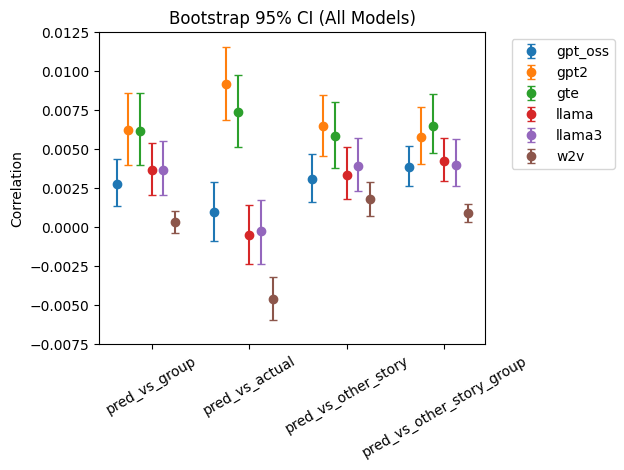

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ディレクトリ
input_dir = "../analysis_corr2/normal_mean"

# モデル一覧
models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]

# 対象列（subj_vs_group除外）
target_cols = ["pred_vs_group", "pred_vs_actual", "pred_vs_other_story", "pred_vs_other_story_group"]

# ブートストラップ
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# 全結果を格納
all_results = {}

for model in models:
    path = os.path.join(input_dir, f"{model}_pieman_to_bronx_mean_clean.csv")
    df = pd.read_csv(path)

    model_result = {}
    for col in target_cols:
        mean, lower, upper = bootstrap_ci(df[col].values)
        model_result[col] = (mean, lower, upper)
    
    all_results[model] = model_result

# ------------------------
# 可視化（モデル比較）
# ------------------------
plt.figure()

x = np.arange(len(target_cols))
width = 0.12  # モデルごとの横ずらし

for i, model in enumerate(models):
    means = [all_results[model][col][0] for col in target_cols]
    lower_err = [means[j] - all_results[model][col][1] for j, col in enumerate(target_cols)]
    upper_err = [all_results[model][col][2] - means[j] for j, col in enumerate(target_cols)]

    plt.errorbar(
        x + i * width,
        means,
        yerr=[lower_err, upper_err],
        fmt='o',
        capsize=3,
        label=model
    )

plt.xticks(x + width * (len(models) / 2), target_cols, rotation=30)
plt.ylabel("Correlation")
plt.ylim(-0.0075, 0.0125)
plt.title("Bootstrap 95% CI (All Models)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../analysis_corr2/pieman_bootstrap_ci_all.png", dpi=300)
plt.show()

In [12]:
import pandas as pd
import os

# 入力・出力ディレクトリ
input_dir = "../analysis_corr"
output_dir = "../analysis_corr2/absolute_mean"

# モデル名一覧
models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]

for model in models:
    input_path = os.path.join(
        input_dir,
        f"{model}_piemanpni_allsubjects_with_bronx_clean_corr_df.csv"
    )
    
    output_path = os.path.join(
        output_dir,
        f"{model}_pieman_to_bronx_mean_abs_clean.csv"  # ← ファイル名変更
    )
    
    # 読み込み
    df = pd.read_csv(input_path)
    
    # 数値列だけ抽出（parcelも含まれるので後で戻す）
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    
    # parcelは絶対値取らないので除外
    numeric_cols.remove("parcel")
    
    # 絶対値を取る
    df[numeric_cols] = df[numeric_cols].abs()
    
    # parcelごとに平均
    df_mean = df.groupby("parcel").mean(numeric_only=True).reset_index()
    
    # network列を復元
    network = df.groupby("parcel")["network"].first().reset_index()
    df_mean = df_mean.merge(network, on="parcel")
    
    # 保存
    df_mean.to_csv(output_path, index=False)
    
    print(f"Saved: {output_path}")

Saved: ../analysis_corr2/absolute_mean/gpt_oss_pieman_to_bronx_mean_abs_clean.csv
Saved: ../analysis_corr2/absolute_mean/gpt2_pieman_to_bronx_mean_abs_clean.csv
Saved: ../analysis_corr2/absolute_mean/gte_pieman_to_bronx_mean_abs_clean.csv
Saved: ../analysis_corr2/absolute_mean/llama_pieman_to_bronx_mean_abs_clean.csv
Saved: ../analysis_corr2/absolute_mean/llama3_pieman_to_bronx_mean_abs_clean.csv
Saved: ../analysis_corr2/absolute_mean/w2v_pieman_to_bronx_mean_abs_clean.csv


In [13]:
import pandas as pd
import os

# 入力・出力ディレクトリ
input_dir = "../analysis_corr"
output_dir = "../analysis_corr2/absolute_mean"

# モデル名一覧
models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]

for model in models:
    input_path = os.path.join(
        input_dir,
        f"{model}_bronx_allsubjects_with_piemanpni_clean_corr_df.csv"
    )
    
    output_path = os.path.join(
        output_dir,
        f"{model}_bronx_to_pieman_mean_abs_clean.csv"  # ← ファイル名変更
    )
    
    # 読み込み
    df = pd.read_csv(input_path)
    
    # 数値列だけ抽出（parcelも含まれるので後で戻す）
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    
    # parcelは絶対値取らないので除外
    numeric_cols.remove("parcel")
    
    # 絶対値を取る
    df[numeric_cols] = df[numeric_cols].abs()
    
    # parcelごとに平均
    df_mean = df.groupby("parcel").mean(numeric_only=True).reset_index()
    
    # network列を復元
    network = df.groupby("parcel")["network"].first().reset_index()
    df_mean = df_mean.merge(network, on="parcel")
    
    # 保存
    df_mean.to_csv(output_path, index=False)
    
    print(f"Saved: {output_path}")

Saved: ../analysis_corr2/absolute_mean/gpt_oss_bronx_to_pieman_mean_abs_clean.csv
Saved: ../analysis_corr2/absolute_mean/gpt2_bronx_to_pieman_mean_abs_clean.csv
Saved: ../analysis_corr2/absolute_mean/gte_bronx_to_pieman_mean_abs_clean.csv
Saved: ../analysis_corr2/absolute_mean/llama_bronx_to_pieman_mean_abs_clean.csv
Saved: ../analysis_corr2/absolute_mean/llama3_bronx_to_pieman_mean_abs_clean.csv
Saved: ../analysis_corr2/absolute_mean/w2v_bronx_to_pieman_mean_abs_clean.csv


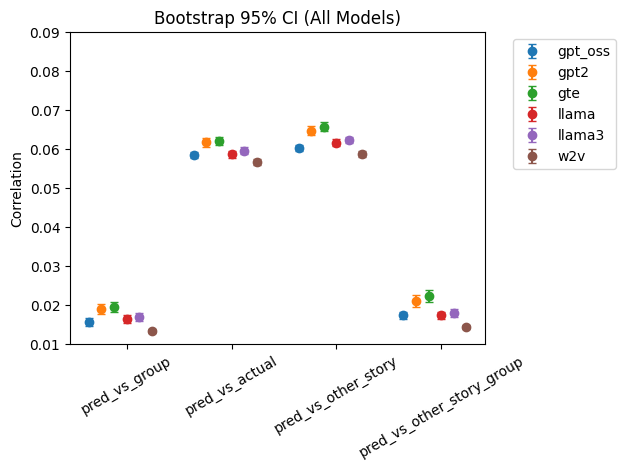

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ディレクトリ
input_dir = "../analysis_corr2/absolute_mean"

# モデル一覧
models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]

# 対象列（subj_vs_group除外）
target_cols = ["pred_vs_group", "pred_vs_actual", "pred_vs_other_story", "pred_vs_other_story_group"]

# ブートストラップ
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# 全結果を格納
all_results = {}

for model in models:
    path = os.path.join(input_dir, f"{model}_bronx_to_pieman_mean_abs_clean.csv")
    df = pd.read_csv(path)

    model_result = {}
    for col in target_cols:
        mean, lower, upper = bootstrap_ci(df[col].values)
        model_result[col] = (mean, lower, upper)
    
    all_results[model] = model_result

# ------------------------
# 可視化（モデル比較）
# ------------------------
plt.figure()

x = np.arange(len(target_cols))
width = 0.12  # モデルごとの横ずらし

for i, model in enumerate(models):
    means = [all_results[model][col][0] for col in target_cols]
    lower_err = [means[j] - all_results[model][col][1] for j, col in enumerate(target_cols)]
    upper_err = [all_results[model][col][2] - means[j] for j, col in enumerate(target_cols)]

    plt.errorbar(
        x + i * width,
        means,
        yerr=[lower_err, upper_err],
        fmt='o',
        capsize=3,
        label=model
    )

plt.xticks(x + width * (len(models) / 2), target_cols, rotation=30)
plt.ylabel("Correlation")
plt.ylim(0.01, 0.09)
plt.title("Bootstrap 95% CI (All Models)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../analysis_corr2/bronx_bootstrap_ci_abs_all.png", dpi=300)
plt.show()

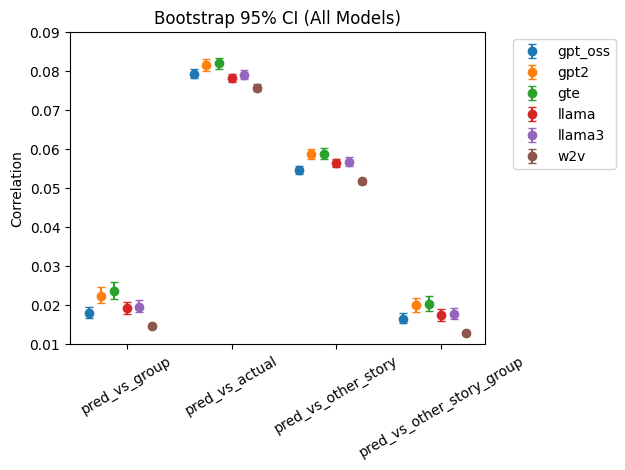

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ディレクトリ
input_dir = "../analysis_corr2/absolute_mean"

# モデル一覧
models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]

# 対象列（subj_vs_group除外）
target_cols = ["pred_vs_group", "pred_vs_actual", "pred_vs_other_story", "pred_vs_other_story_group"]

# ブートストラップ
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# 全結果を格納
all_results = {}

for model in models:
    path = os.path.join(input_dir, f"{model}_pieman_to_bronx_mean_abs_clean.csv")
    df = pd.read_csv(path)

    model_result = {}
    for col in target_cols:
        mean, lower, upper = bootstrap_ci(df[col].values)
        model_result[col] = (mean, lower, upper)
    
    all_results[model] = model_result

# ------------------------
# 可視化（モデル比較）
# ------------------------
plt.figure()

x = np.arange(len(target_cols))
width = 0.12  # モデルごとの横ずらし

for i, model in enumerate(models):
    means = [all_results[model][col][0] for col in target_cols]
    lower_err = [means[j] - all_results[model][col][1] for j, col in enumerate(target_cols)]
    upper_err = [all_results[model][col][2] - means[j] for j, col in enumerate(target_cols)]

    plt.errorbar(
        x + i * width,
        means,
        yerr=[lower_err, upper_err],
        fmt='o',
        capsize=3,
        label=model
    )

plt.xticks(x + width * (len(models) / 2), target_cols, rotation=30)
plt.ylabel("Correlation")
plt.title("Bootstrap 95% CI (All Models)")
plt.ylim(0.01, 0.09)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../analysis_corr2/pieman_bootstrap_ci_abs_all.png", dpi=300)
plt.show()

In [20]:
import pandas as pd
import os

input_dir = "../analysis_corr2/normal_mean"
output_dir = "../analysis_corr2/isc_base_mean"

models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]

for model in models:
    input_path = os.path.join(
        input_dir,
        f"{model}_pieman_to_bronx_mean_clean.csv"
    )
    
    output_path = os.path.join(
        output_dir,
        f"{model}_pieman_to_bronx_isc_normalized.csv"
    )
    
    df = pd.read_csv(input_path)
    
    # 0除算防止（重要）
    df = df[df["subj_vs_group"] != 0].copy()
    
    # 正規化
    df["pred_vs_group_norm"] = df["pred_vs_group"] / df["subj_vs_group"]
    df["pred_vs_actual_norm"] = df["pred_vs_actual"] / df["subj_vs_group"]
    df["pred_vs_other_story_norm"] = df["pred_vs_other_story"] / df["subj_vs_group"]
    df["pred_vs_other_story_group_norm"] = df["pred_vs_other_story_group"] / df["subj_vs_group"]
    
    # 必要なら元列を残したままでもOK
    df.to_csv(output_path, index=False)
    
    print(f"Saved: {output_path}")

Saved: ../analysis_corr2/isc_base_mean/gpt_oss_pieman_to_bronx_isc_normalized.csv
Saved: ../analysis_corr2/isc_base_mean/gpt2_pieman_to_bronx_isc_normalized.csv
Saved: ../analysis_corr2/isc_base_mean/gte_pieman_to_bronx_isc_normalized.csv
Saved: ../analysis_corr2/isc_base_mean/llama_pieman_to_bronx_isc_normalized.csv
Saved: ../analysis_corr2/isc_base_mean/llama3_pieman_to_bronx_isc_normalized.csv
Saved: ../analysis_corr2/isc_base_mean/w2v_pieman_to_bronx_isc_normalized.csv


In [21]:
import pandas as pd
import os

input_dir = "../analysis_corr2/normal_mean"
output_dir = "../analysis_corr2/isc_base_mean"

models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]

for model in models:
    input_path = os.path.join(
        input_dir,
        f"{model}_bronx_to_pieman_mean_clean.csv"
    )
    
    output_path = os.path.join(
        output_dir,
        f"{model}_bronx_to_pieman_isc_normalized.csv"
    )
    
    df = pd.read_csv(input_path)
    
    # 0除算防止（重要）
    df = df[df["subj_vs_group"] != 0].copy()
    
    # 正規化
    df["pred_vs_group_norm"] = df["pred_vs_group"] / df["subj_vs_group"]
    df["pred_vs_actual_norm"] = df["pred_vs_actual"] / df["subj_vs_group"]
    df["pred_vs_other_story_norm"] = df["pred_vs_other_story"] / df["subj_vs_group"]
    df["pred_vs_other_story_group_norm"] = df["pred_vs_other_story_group"] / df["subj_vs_group"]
    
    # 必要なら元列を残したままでもOK
    df.to_csv(output_path, index=False)
    
    print(f"Saved: {output_path}")

Saved: ../analysis_corr2/isc_base_mean/gpt_oss_bronx_to_pieman_isc_normalized.csv
Saved: ../analysis_corr2/isc_base_mean/gpt2_bronx_to_pieman_isc_normalized.csv
Saved: ../analysis_corr2/isc_base_mean/gte_bronx_to_pieman_isc_normalized.csv
Saved: ../analysis_corr2/isc_base_mean/llama_bronx_to_pieman_isc_normalized.csv
Saved: ../analysis_corr2/isc_base_mean/llama3_bronx_to_pieman_isc_normalized.csv
Saved: ../analysis_corr2/isc_base_mean/w2v_bronx_to_pieman_isc_normalized.csv


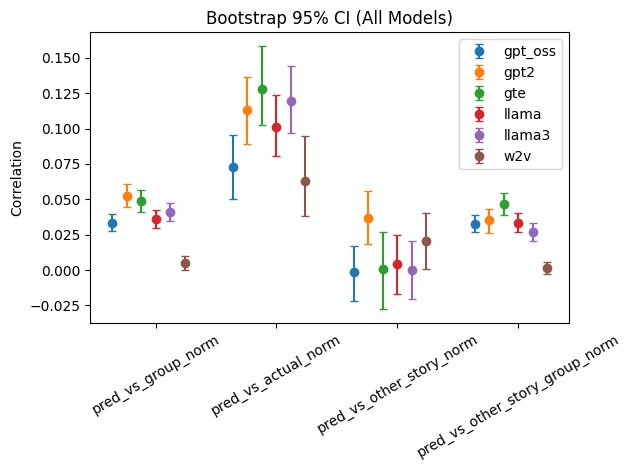

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ディレクトリ
input_dir = "../analysis_corr2/isc_base_mean"

# モデル一覧
models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]

# 対象列（subj_vs_group除外）
target_cols = ["pred_vs_group_norm", "pred_vs_actual_norm", "pred_vs_other_story_norm", "pred_vs_other_story_group_norm"]

# ブートストラップ
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# 全結果を格納
all_results = {}

for model in models:
    path = os.path.join(input_dir, f"{model}_bronx_to_pieman_isc_normalized.csv")
    df = pd.read_csv(path)

    model_result = {}
    for col in target_cols:
        mean, lower, upper = bootstrap_ci(df[col].values)
        model_result[col] = (mean, lower, upper)
    
    all_results[model] = model_result

# ------------------------
# 可視化（モデル比較）
# ------------------------
plt.figure()

x = np.arange(len(target_cols))
width = 0.12  # モデルごとの横ずらし

for i, model in enumerate(models):
    means = [all_results[model][col][0] for col in target_cols]
    lower_err = [means[j] - all_results[model][col][1] for j, col in enumerate(target_cols)]
    upper_err = [all_results[model][col][2] - means[j] for j, col in enumerate(target_cols)]

    plt.errorbar(
        x + i * width,
        means,
        yerr=[lower_err, upper_err],
        fmt='o',
        capsize=3,
        label=model
    )

plt.xticks(x + width * (len(models) / 2), target_cols, rotation=30)
plt.ylabel("Correlation")
plt.title("Bootstrap 95% CI (All Models)")
plt.legend()
plt.tight_layout()
plt.savefig("../analysis_corr2/bronx_bootstrap_ci_isc_base_all.png", dpi=300)
plt.show()

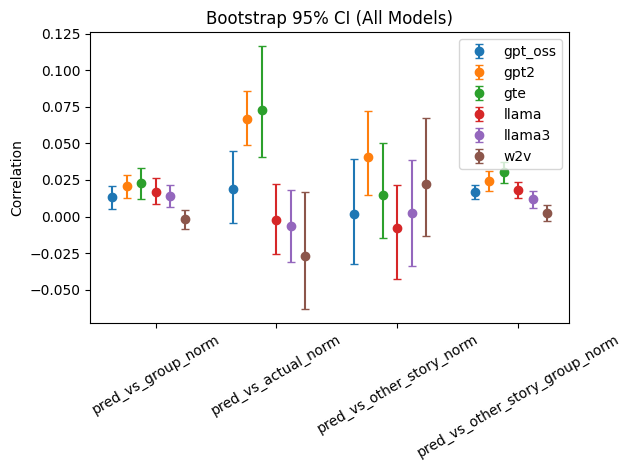

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ディレクトリ
input_dir = "../analysis_corr2/isc_base_mean"

# モデル一覧
models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]

# 対象列（subj_vs_group除外）
target_cols = ["pred_vs_group_norm", "pred_vs_actual_norm", "pred_vs_other_story_norm", "pred_vs_other_story_group_norm"]

# ブートストラップ
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# 全結果を格納
all_results = {}

for model in models:
    path = os.path.join(input_dir, f"{model}_pieman_to_bronx_isc_normalized.csv")
    df = pd.read_csv(path)

    model_result = {}
    for col in target_cols:
        mean, lower, upper = bootstrap_ci(df[col].values)
        model_result[col] = (mean, lower, upper)
    
    all_results[model] = model_result

# ------------------------
# 可視化（モデル比較）
# ------------------------
plt.figure()

x = np.arange(len(target_cols))
width = 0.12  # モデルごとの横ずらし

for i, model in enumerate(models):
    means = [all_results[model][col][0] for col in target_cols]
    lower_err = [means[j] - all_results[model][col][1] for j, col in enumerate(target_cols)]
    upper_err = [all_results[model][col][2] - means[j] for j, col in enumerate(target_cols)]

    plt.errorbar(
        x + i * width,
        means,
        yerr=[lower_err, upper_err],
        fmt='o',
        capsize=3,
        label=model
    )

plt.xticks(x + width * (len(models) / 2), target_cols, rotation=30)
plt.ylabel("Correlation")
plt.title("Bootstrap 95% CI (All Models)")
plt.legend()
plt.tight_layout()
plt.savefig("../analysis_corr2/pieman_bootstrap_ci_isc_base_all.png", dpi=300)
plt.show()

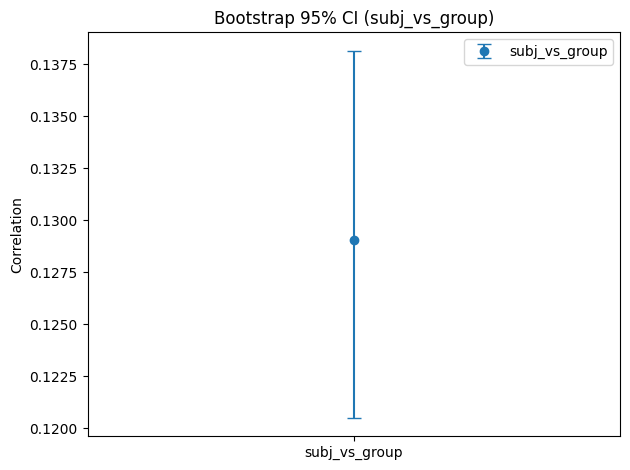

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ディレクトリ
input_dir = "../analysis_corr2/normal_mean"

# どのモデルでも同じなので1つだけ使う
model = "gpt2"  # 何でもOK

# ブートストラップ
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# データ読み込み
path = os.path.join(input_dir, f"{model}_pieman_to_bronx_mean_clean.csv")
df = pd.read_csv(path)

# subj_vs_groupのみ
mean, lower, upper = bootstrap_ci(df["subj_vs_group"].values)

# ------------------------
# 可視化
# ------------------------
plt.figure()

plt.errorbar(
    0,
    mean,
    yerr=[[mean - lower], [upper - mean]],
    fmt='o',
    capsize=5,
    label="subj_vs_group"
)

plt.xticks([0], ["subj_vs_group"])
plt.ylabel("Correlation")

plt.title("Bootstrap 95% CI (subj_vs_group)")

plt.legend()
plt.tight_layout()
plt.savefig("../analysis_corr2/pieman_isc_ci.png", dpi=300)
plt.show()

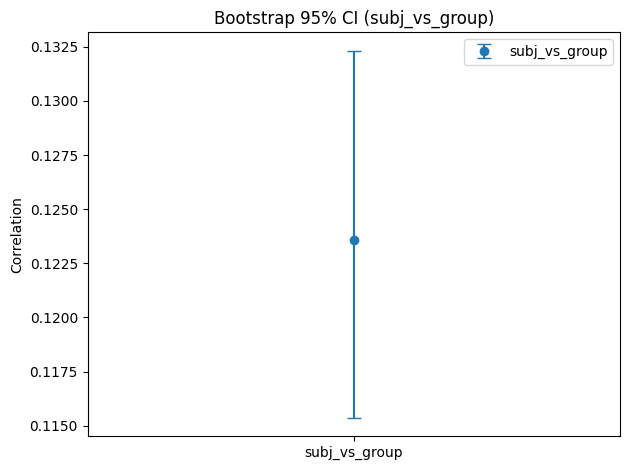

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ディレクトリ
input_dir = "../analysis_corr2/normal_mean"

# どのモデルでも同じなので1つだけ使う
model = "gpt2"  # 何でもOK

# ブートストラップ
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# データ読み込み
path = os.path.join(input_dir, f"{model}_bronx_to_pieman_mean_clean.csv")
df = pd.read_csv(path)

# subj_vs_groupのみ
mean, lower, upper = bootstrap_ci(df["subj_vs_group"].values)

# ------------------------
# 可視化
# ------------------------
plt.figure()

plt.errorbar(
    0,
    mean,
    yerr=[[mean - lower], [upper - mean]],
    fmt='o',
    capsize=5,
    label="subj_vs_group"
)

plt.xticks([0], ["subj_vs_group"])
plt.ylabel("Correlation")

plt.title("Bootstrap 95% CI (subj_vs_group)")

plt.legend()
plt.tight_layout()
plt.savefig("../analysis_corr2/bronx_isc_ci.png", dpi=300)
plt.show()

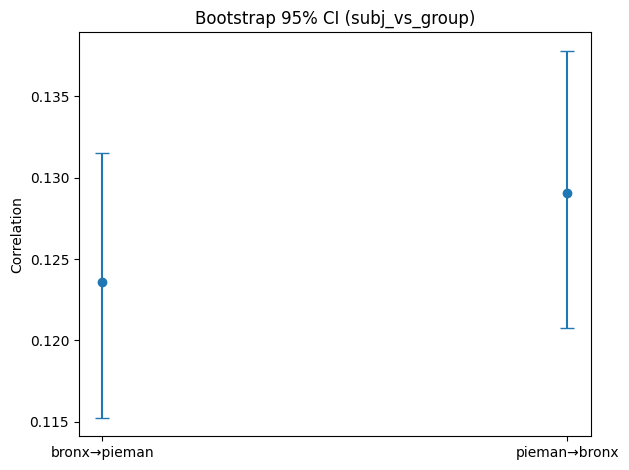

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ディレクトリ
input_dir = "../analysis_corr2/normal_mean"

model = "gpt2"  # 何でもOK

# ブートストラップ
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# ------------------------
# 2条件の計算
# ------------------------
results = []

# bronx → pieman
path1 = os.path.join(input_dir, f"{model}_bronx_to_pieman_mean_clean.csv")
df1 = pd.read_csv(path1)
mean1, lower1, upper1 = bootstrap_ci(df1["subj_vs_group"].values)
results.append((mean1, lower1, upper1))

# pieman → bronx
path2 = os.path.join(input_dir, f"{model}_pieman_to_bronx_mean_clean.csv")
df2 = pd.read_csv(path2)
mean2, lower2, upper2 = bootstrap_ci(df2["subj_vs_group"].values)
results.append((mean2, lower2, upper2))

# ------------------------
# 可視化
# ------------------------
plt.figure()

x = np.arange(2)
labels = ["bronx→pieman", "pieman→bronx"]

means = [r[0] for r in results]
lower_err = [means[i] - results[i][1] for i in range(2)]
upper_err = [results[i][2] - means[i] for i in range(2)]

plt.errorbar(
    x,
    means,
    yerr=[lower_err, upper_err],
    fmt='o',
    capsize=5
)

plt.xticks(x, labels)
plt.ylabel("Correlation")
plt.title("Bootstrap 95% CI (subj_vs_group)")

plt.tight_layout()
plt.savefig("../analysis_corr2/isc_compar.png", dpi=300)
plt.show()

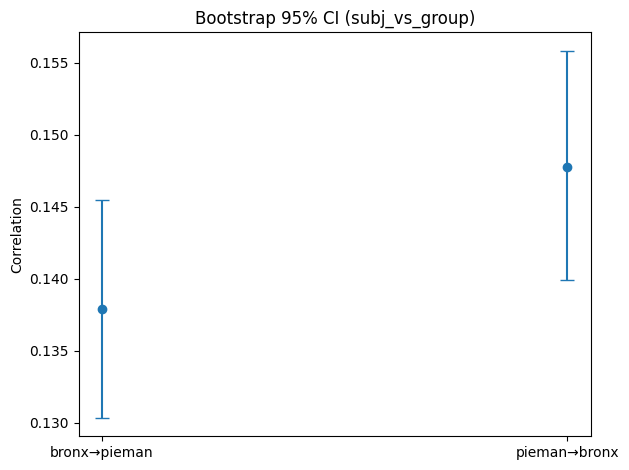

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ディレクトリ
input_dir = "../analysis_corr2/absolute_mean"

model = "gpt2"  # 何でもOK

# ブートストラップ
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# ------------------------
# 2条件の計算
# ------------------------
results = []

# bronx → pieman
path1 = os.path.join(input_dir, f"{model}_bronx_to_pieman_mean_abs_clean.csv")
df1 = pd.read_csv(path1)
mean1, lower1, upper1 = bootstrap_ci(df1["subj_vs_group"].values)
results.append((mean1, lower1, upper1))

# pieman → bronx
path2 = os.path.join(input_dir, f"{model}_pieman_to_bronx_mean_abs_clean.csv")
df2 = pd.read_csv(path2)
mean2, lower2, upper2 = bootstrap_ci(df2["subj_vs_group"].values)
results.append((mean2, lower2, upper2))

# ------------------------
# 可視化
# ------------------------
plt.figure()

x = np.arange(2)
labels = ["bronx→pieman", "pieman→bronx"]

means = [r[0] for r in results]
lower_err = [means[i] - results[i][1] for i in range(2)]
upper_err = [results[i][2] - means[i] for i in range(2)]

plt.errorbar(
    x,
    means,
    yerr=[lower_err, upper_err],
    fmt='o',
    capsize=5
)

plt.xticks(x, labels)
plt.ylabel("Correlation")
plt.title("Bootstrap 95% CI (subj_vs_group)")

plt.tight_layout()
plt.savefig("../analysis_corr2/isc_compar_abs.png", dpi=300)
plt.show()

# EAC DMN に注目

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

input_dir = "../analysis_corr2/normal_mean"
output_dir = "../analysis_corr2/figures"
os.makedirs(output_dir, exist_ok=True)

models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]
target_cols = ["pred_vs_group", "pred_vs_actual", "pred_vs_other_story", "pred_vs_other_story_group"]

# ------------------------
# index定義
# ------------------------
EAC_idx = list(range(32, 69)) + list(range(231, 271))
DMN_idx = list(range(149, 201)) + list(range(362, 401))

# 0-indexに変換
EAC_idx = [i-1 for i in EAC_idx]
DMN_idx = [i-1 for i in DMN_idx]

# ------------------------
# bootstrap
# ------------------------
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# ------------------------
# 汎用処理関数
# ------------------------
def compute_results(df, indices=None):
    result = {}
    for col in target_cols:
        if indices is not None:
            data = df[col].values[indices]
        else:
            data = df[col].values

        mean, lower, upper = bootstrap_ci(data)
        result[col] = (mean, lower, upper)
    return result

# ------------------------
# 全結果格納
# ------------------------
all_results = {}
eac_results = {}
dmn_results = {}

for model in models:
    path = os.path.join(input_dir, f"{model}_bronx_to_pieman_mean_clean.csv")
    df = pd.read_csv(path)

    all_results[model] = compute_results(df)
    eac_results[model] = compute_results(df, EAC_idx)
    dmn_results[model] = compute_results(df, DMN_idx)

# ------------------------
# 描画関数
# ------------------------
def plot_results(results_dict, title, save_path):
    plt.figure()
    x = np.arange(len(target_cols))
    width = 0.12

    for i, model in enumerate(models):
        means = [results_dict[model][col][0] for col in target_cols]
        lower_err = [means[j] - results_dict[model][col][1] for j, col in enumerate(target_cols)]
        upper_err = [results_dict[model][col][2] - means[j] for j, col in enumerate(target_cols)]

        plt.errorbar(
            x + i * width,
            means,
            yerr=[lower_err, upper_err],
            fmt='o',
            capsize=3,
            label=model
        )

    plt.xticks(x + width * (len(models) / 2), target_cols, rotation=30)
    plt.ylabel("Correlation")
    plt.ylim(-0.0075, 0.0125)
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

# ------------------------
# ① 全体比較（3枚）
# ------------------------
plot_results(all_results, "All Parcels", f"{output_dir}/all_parcels.png")
plot_results(eac_results, "EAC Parcels", f"{output_dir}/eac.png")
plot_results(dmn_results, "DMN Parcels", f"{output_dir}/dmn.png")

# ------------------------
# ② モデルごと（3枚）
# ------------------------
for name, results_dict in zip(
    ["all", "eac", "dmn"],
    [all_results, eac_results, dmn_results]
):
    plt.figure()
    x = np.arange(len(models))
    width = 0.18

    for i, col in enumerate(target_cols):
        means = [results_dict[m][col][0] for m in models]
        lower_err = [means[j] - results_dict[m][col][1] for j, m in enumerate(models)]
        upper_err = [results_dict[m][col][2] - means[j] for j, m in enumerate(models)]

        plt.errorbar(
            x + i * width,
            means,
            yerr=[lower_err, upper_err],
            fmt='o',
            capsize=3,
            label=col
        )

    plt.xticks(x + width * (len(target_cols) / 2), models, rotation=30)
    plt.ylabel("Correlation")
    plt.title(f"{name.upper()} (Model-wise)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{name}_modelwise.png", dpi=300)
    plt.close()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------
# 設定
# ------------------------
input_dir = "../analysis_corr2/normal_mean"
output_dir = "../analysis_corr2/figures"
os.makedirs(output_dir, exist_ok=True)

models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]
display_names = {
    "gpt_oss": "gpt_oss",
    "gpt2": "gpt2",
    "gte": "e5",
    "llama": "mistral",
    "llama3": "llama3",
    "w2v": "w2v"
}
target_cols = ["pred_vs_group", "pred_vs_actual", "pred_vs_other_story", "pred_vs_other_story_group"]

display_labels = [
    "pred vs group (SS)",
    "pred vs actual (SS)",
    "pred vs actual (CS)",
    "pred vs group (CS)"
]

# ------------------------
# index定義
# ------------------------
EAC_idx = list(range(32, 69)) + list(range(231, 271))
DMN_idx = list(range(149, 201)) + list(range(362, 401))

EAC_idx = [i-1 for i in EAC_idx]
DMN_idx = [i-1 for i in DMN_idx]

# ------------------------
# bootstrap
# ------------------------
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# ------------------------
# 計算関数
# ------------------------
def compute(df, idx=None):
    result = {}
    for col in target_cols:
        data = df[col].values if idx is None else df[col].values[idx]
        result[col] = bootstrap_ci(data)
    return result

# ------------------------
# 全結果
# ------------------------
all_res = {}
eac_res = {}
dmn_res = {}

for model in models:
    df = pd.read_csv(os.path.join(input_dir, f"{model}_bronx_to_pieman_mean_clean.csv"))

    all_res[model] = compute(df)
    eac_res[model] = compute(df, EAC_idx)
    dmn_res[model] = compute(df, DMN_idx)

# =========================
# ① EACまとめ（全モデル）
# =========================
plt.figure()
x = np.arange(len(target_cols))
width = 0.12

for i, model in enumerate(models):
    means = [eac_res[model][c][0] for c in target_cols]
    lower = [means[j] - eac_res[model][c][1] for j, c in enumerate(target_cols)]
    upper = [eac_res[model][c][2] - means[j] for j, c in enumerate(target_cols)]

    plt.errorbar(x + i*width, means, yerr=[lower, upper], fmt='o', capsize=3, label=display_names[model])

plt.xticks(x + width*len(models)/2, display_labels, rotation=30)
plt.title("train : bronx -- EAC (All Models)")
plt.ylabel("Correlation")
plt.ylim(-0.01, 0.035)
#plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.savefig(f"{output_dir}/bronx_EAC_all_models.png", dpi=300)
plt.close()

# =========================
# ② DMNまとめ（全モデル）
# =========================
plt.figure()

for i, model in enumerate(models):
    means = [dmn_res[model][c][0] for c in target_cols]
    lower = [means[j] - dmn_res[model][c][1] for j, c in enumerate(target_cols)]
    upper = [dmn_res[model][c][2] - means[j] for j, c in enumerate(target_cols)]

    plt.errorbar(x + i*width, means, yerr=[lower, upper], fmt='o', capsize=3, label=display_names[model])

plt.xticks(x + width*len(models)/2, display_labels, rotation=30)
plt.title("train : bronx -- DMN (All Models)")
plt.ylabel("Correlation")
#plt.legend(bbox_to_anchor=(1.05,1))
plt.ylim(-0.01, 0.035)
plt.tight_layout()
plt.savefig(f"{output_dir}/bronx_DMN_all_models.png", dpi=300)
plt.close()

# =========================
# ③ モデルごと（All vs EAC vs DMN）
# =========================
for model in models:
    plt.figure()
    x = np.arange(len(target_cols))
    width = 0.2

    for i, (name, res_dict) in enumerate(
        zip(["All", "EAC", "DMN"], [all_res, eac_res, dmn_res])
    ):
        means = [res_dict[model][c][0] for c in target_cols]
        lower = [means[j] - res_dict[model][c][1] for j, c in enumerate(target_cols)]
        upper = [res_dict[model][c][2] - means[j] for j, c in enumerate(target_cols)]

        plt.errorbar(x + i*width, means, yerr=[lower, upper], fmt='o', capsize=3, label=display_names[model])

    plt.xticks(x + width, display_labels, rotation=30)
    plt.title(f"train : pieman -- {model}: All vs EAC vs DMN")
    plt.ylabel("Correlation")
    #plt.legend()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/bronx_{model}_compare.png", dpi=300)
    plt.close()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------
# 設定
# ------------------------
input_dir = "../analysis_corr2/normal_mean"
output_dir = "../analysis_corr2/figures"
os.makedirs(output_dir, exist_ok=True)

models = ["gpt_oss", "gpt2", "gte", "llama", "llama3", "w2v"]
display_names = {
    "gpt_oss": "gpt_oss",
    "gpt2": "gpt2",
    "gte": "e5",
    "llama": "mistral",
    "llama3": "llama3",
    "w2v": "w2v"
}
target_cols = ["pred_vs_group", "pred_vs_actual", "pred_vs_other_story", "pred_vs_other_story_group"]

# ------------------------
# index定義
# ------------------------
EAC_idx = list(range(32, 69)) + list(range(231, 271))
DMN_idx = list(range(149, 201)) + list(range(362, 401))

EAC_idx = [i-1 for i in EAC_idx]
DMN_idx = [i-1 for i in DMN_idx]

# ------------------------
# bootstrap
# ------------------------
def bootstrap_ci(data, n_boot=2000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper

# ------------------------
# 計算関数
# ------------------------
def compute(df, idx=None):
    result = {}
    for col in target_cols:
        data = df[col].values if idx is None else df[col].values[idx]
        result[col] = bootstrap_ci(data)
    return result

# ------------------------
# 全結果
# ------------------------
all_res = {}
eac_res = {}
dmn_res = {}

for model in models:
    df = pd.read_csv(os.path.join(input_dir, f"{model}_pieman_to_bronx_mean_clean.csv"))

    all_res[model] = compute(df)
    eac_res[model] = compute(df, EAC_idx)
    dmn_res[model] = compute(df, DMN_idx)

# =========================
# ① EACまとめ（全モデル）
# =========================
plt.figure()
x = np.arange(len(target_cols))
width = 0.12

for i, model in enumerate(models):
    means = [eac_res[model][c][0] for c in target_cols]
    lower = [means[j] - eac_res[model][c][1] for j, c in enumerate(target_cols)]
    upper = [eac_res[model][c][2] - means[j] for j, c in enumerate(target_cols)]

    plt.errorbar(x + i*width, means, yerr=[lower, upper], fmt='o', capsize=3, label=display_names[model])

plt.xticks(x + width*len(models)/2, display_labels, rotation=30)
plt.title("train : pieman -- EAC (All Models)")
plt.ylabel("Correlation")
plt.ylim(-0.01, 0.035)
#plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.savefig(f"{output_dir}/pieman_EAC_all_models.png", dpi=300)
plt.close()

# =========================
# ② DMNまとめ（全モデル）
# =========================
plt.figure()

for i, model in enumerate(models):
    means = [dmn_res[model][c][0] for c in target_cols]
    lower = [means[j] - dmn_res[model][c][1] for j, c in enumerate(target_cols)]
    upper = [dmn_res[model][c][2] - means[j] for j, c in enumerate(target_cols)]

    plt.errorbar(x + i*width, means, yerr=[lower, upper], fmt='o', capsize=3, label=display_names[model])

plt.xticks(x + width*len(models)/2, display_labels, rotation=30)
plt.title("train : pieman -- DMN (All Models)")
plt.ylabel("Correlation")
plt.ylim(-0.01, 0.035)
#plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.savefig(f"{output_dir}/pieman_DMN_all_models.png", dpi=300)
plt.close()

# =========================
# ③ モデルごと（All vs EAC vs DMN）
# =========================
for model in models:
    plt.figure()
    x = np.arange(len(target_cols))
    width = 0.2

    for i, (name, res_dict) in enumerate(
        zip(["All", "EAC", "DMN"], [all_res, eac_res, dmn_res])
    ):
        means = [res_dict[model][c][0] for c in target_cols]
        lower = [means[j] - res_dict[model][c][1] for j, c in enumerate(target_cols)]
        upper = [res_dict[model][c][2] - means[j] for j, c in enumerate(target_cols)]

        plt.errorbar(x + i*width, means, yerr=[lower, upper], fmt='o', capsize=3, label=display_names[model])

    plt.xticks(x + width, display_labels, rotation=30)
    plt.title(f"train : pieman -- {model}: All vs EAC vs DMN")
    plt.ylabel("Correlation")
    #plt.legend()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/pieman_{model}_compare.png", dpi=300)
    plt.close()

In [8]:
# =========================
# 凡例だけ保存
# =========================
fig, ax = plt.subplots(figsize=(4, 2))

# ダミープロット
for model in models:
    ax.plot(
        [],
        [],
        'o',
        label=display_names[model]
    )

# 軸を消す
ax.axis('off')

# 凡例作成
legend = ax.legend(
    loc='center',
    frameon=False,
    ncol=2
)

# 保存
fig.savefig(
    f"{output_dir}/legend.png",
    dpi=300,
    bbox_inches='tight'
)

plt.close()

In [10]:
# =========================
# 比較図用凡例
# =========================
fig, ax = plt.subplots(figsize=(3, 2))

compare_labels = ["All", "EAC", "DMN"]

for label in compare_labels:
    ax.plot([], [], 'o', label=label)

ax.axis('off')

ax.legend(
    loc='center',
    frameon=False,
    ncol=3
)

fig.savefig(
    f"{output_dir}/compare_legend.png",
    dpi=300,
    bbox_inches='tight'
)

plt.close()